**SIFT**

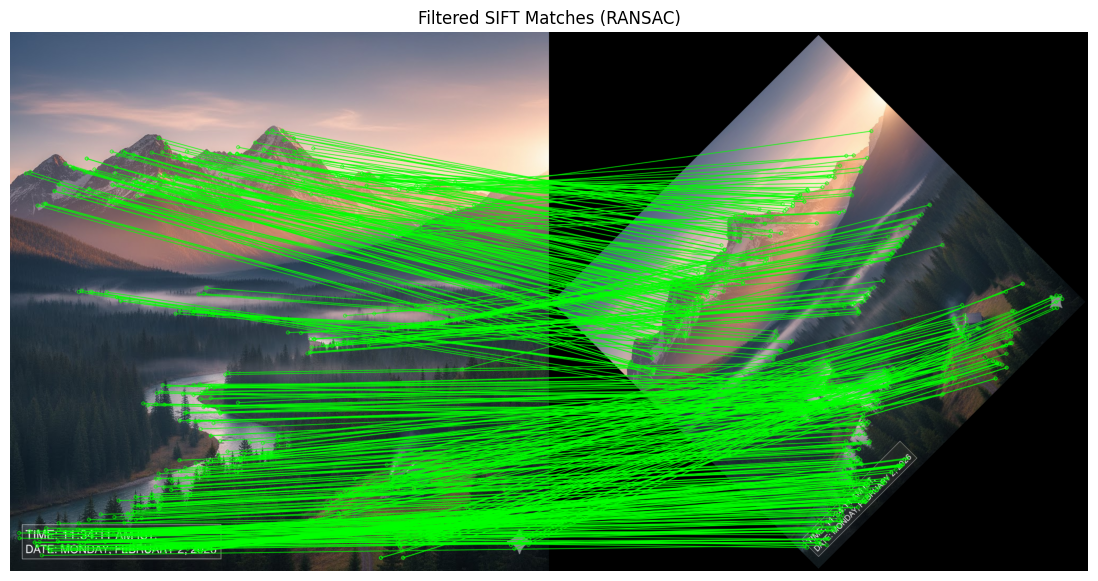

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and prepare images
img1 = cv2.imread('/content/unnamed.jpg')
# Creating a more complex transformation (Rotation + Scaling)
rows, cols, _ = img1.shape
M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 0.7)
img2 = cv2.warpAffine(img1, M, (cols, rows))

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 2. Extract SIFT Features
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# 3. Match using FLANN (Faster than Brute Force for large datasets)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# 4. Ratio Test
good = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)

# 5. RANSAC Geometric Verification
if len(good) > 10:
    # Extract locations of matched keypoints
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # Find the transformation matrix (Homography)
    # mask tells us which points are 'Inliers'
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matchesMask = mask.ravel().tolist()
else:
    print("Not enough matches found!")
    matchesMask = None

# 6. Draw "Clean" Matches
draw_params = dict(matchColor=(0, 255, 0), # draw matches in green
                   singlePointColor=None,
                   matchesMask=matchesMask, # draw only inliers
                   flags=2)

result_img = cv2.drawMatches(img1, kp1, img2, kp2, good, None, **draw_params)

plt.figure(figsize=(15, 7))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title("Filtered SIFT Matches (RANSAC)")
plt.axis('off')
plt.show()

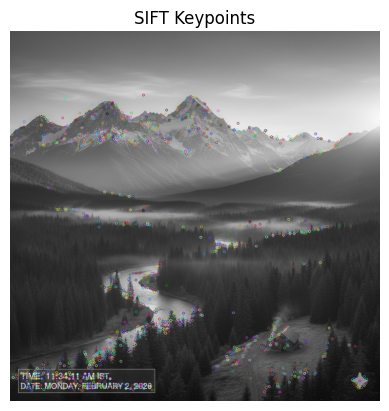

In [ ]:
kp_img = cv2.drawKeypoints(gray1, kp1, None)
plt.imshow(kp_img, cmap='gray')
plt.title("SIFT Keypoints")
plt.axis('off')
plt.show()

**HOG_and_SVM.ipynb**

Using Colab cache for faster access to the 'pedestrian-detection' dataset.
Testing on image: image (141).jpg


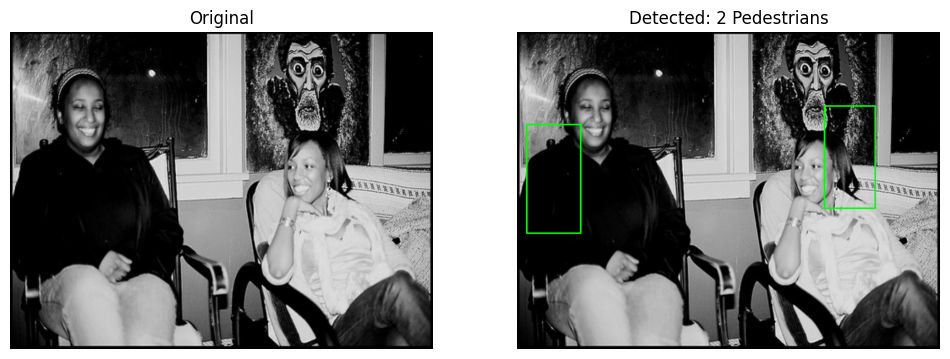

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
import random

# ---------- 1. Download Dataset ----------
path = kagglehub.dataset_download("karthika95/pedestrian-detection")

# Recursively find all images
image_files = []
for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_files.append(os.path.join(root, file))

if not image_files:
    raise FileNotFoundError("No image files found.")

# Select a RANDOM image instead of the first one
img_path = random.choice(image_files)
print(f"Testing on image: {os.path.basename(img_path)}")

# ---------- 2. Initialize HOG + SVM ----------
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# ---------- 3. Load and Process Image ----------
image = cv2.imread(img_path)
# Standardize size for better detection consistency
image = cv2.resize(image, (800, 600))
orig = image.copy()

# ---------- 4. Detect Pedestrians ----------
# Higher hitThreshold (0.1 - 0.5) reduces false positives
(rects, weights) = hog.detectMultiScale(image, winStride=(8, 8),
                                        padding=(16, 16), scale=1.05)

# ---------- 5. Apply Non-Maximum Suppression (NMS) ----------
rects_fmt = np.array([[x, y, x + w, y + h] for (x, y, w, h) in rects])
pick = cv2.dnn.NMSBoxes(rects_fmt.tolist(), np.array(weights).flatten().tolist(), 0.5, 0.3)

# ---------- 6. Visualization ----------
if len(pick) > 0:
    for i in pick:
        # Handling different OpenCV versions for NMS output
        idx = i[0] if isinstance(i, (list, np.ndarray)) else i
        (xA, yA, xB, yB) = rects_fmt[idx]
        cv2.rectangle(image, (xA, yA), (xB, yB), (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Detected: {len(pick)} Pedestrians")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()